in this notebook, different componenets to analyse the flight behaviour will be tested

In [4]:
import sys
if "pats" not in sys.path:
    sys.path.insert(0, "pats")  # local scripts live in ./pats

import os
from datetime import datetime, timedelta
from typing import Tuple

import matplotlib.pyplot as plt
from dotenv import load_dotenv

import logger
from pats_service import PatsService, PatsServiceError
from plot_examples import ExamplePlots


## Username and login

In [5]:
logger.init_logger(logger=logger.logger)

load_dotenv()

user = os.getenv("pats_user")
passw = os.getenv("pats_passw")

service = PatsService(user, passw)


* INFO  - Successfully retrieved API token from server: https://pats-c.com - pats_service.69


In [6]:
sections = service.download_sections()
detection_classes = service.download_detection_classes()


* INFO  - Successfully sections from pats server - pats_service.170
* INFO  - Successfully retrieved detection classes from pats server - pats_service.111


In [7]:
sections = sections[0]

for insect in sections["detection_classes"]:
    print(insect["id"], "-", insect["label"])


64 - No size
1 - Chrysodeixis chalcites
3 - Tuta absoluta
12 - Bombus terrestris
63 - Anomalies


In [8]:
sections = service.download_sections()

print(sections)
print("Available Sections for your account:")

for index, section in enumerate(sections):
    name = section.get("name", "Unnamed Section")
    print(f"Index [{index}] -> Section ID: {section['id']} | Name: {name}")

* INFO  - Successfully sections from pats server - pats_service.170


[{'id': 509, 'name': '', 'greenhouse_name': '1', 'label': '1', 'customer_name': 'Tomatoworld', 'crop': 'Tomato', 'detection_classes': [{'id': 64, 'label': 'No size', 'translations': {'SHORT': 'No size'}, 'available_in_c': 1, 'available_in_trapeye': 0, 'available_in_manual_scouting': 0, 'pest_insect': 0, 'pest_animal': 0, 'pest_fungus': False, 'pest_bacteria': False, 'pest_virus': False, 'natural_enemy': 0, 'pollinator': 0, 'beneficial': 0, 'invert_colors': 0, 'c_level_1': 5, 'c_level_2': 15, 'c_level_3': 30, 'c_level_4': 50, 'trapeye_level_1': None, 'trapeye_level_2': None, 'trapeye_level_3': None, 'trapeye_level_4': None, 'bb_label': None}, {'id': 1, 'label': 'Chrysodeixis chalcites', 'translations': {'LA': 'Chrysodeixis chalcites', 'NL': 'Turkse Mot (Chrysodeixis)', 'EN': 'Tomato looper (Chrysodeixis)', 'FR': 'Noctuelle de la tomate (Chrysodeixis)', 'DE': 'Tomateneule (Chrysodeixis)', 'SHORT': 'Tomato looper / Turkse mot', 'NO': 'Tomatfly (Chrysodeixis)', 'SV': 'Tomatfly (Chrysodeixi

In [9]:

example_section = sections[0]   # of kies een andere index
section_id = example_section["id"]

print("Using section_id:", section_id)

Using section_id: 509


In [10]:
spots = service.download_spots(section_id)

for s in spots["c"]:
    print(
        "row:", s["row_id"],
        "| post:", s["post_id"],
        "| system:", s["system_id"]
    )



* INFO  - Successfully retrieved spots from pats servers - pats_service.229


row: 6 | post: 1 | system: 900
row: 13 | post: 1 | system: 939


In [11]:
some_system_id = spots["c"][0]["system_id"]

some_system_id

900

## Hive-return analysis for 2026-04-19

A "hive return" is any flight track whose **last** valid `(posX_insect, posY_insect, posZ_insect)` sample is within a tolerance of the hive position.


In [16]:
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd

# --- Parameters you can tweak ----------------------------------------------
TARGET_DATE = datetime(2026, 4, 13)

# Hive positions per PATS-C system.
# Each camera has its OWN local coordinate frame, so each one gets its
# own hive position.
hive_900_pos = np.array([-0.04, -0.665, -1.195])     # system_id 900 (row 6)
hive_939_pos = np.array([ -0.086, -0.828, -1.045 ])      # system_id 939 (row 13) -

HIVE_BY_SYSTEM = {
    900: hive_900_pos,
    939: hive_939_pos,
}

TOL = 0.1                                       # metres, sphere radius around hive
BUMBLEBEE_CLASS_ID = 12                         # "Bombus terrestris"

# Which PATS-C sensor(s) to analyse.
#   "both"       -> use every PATS-C sensor in the section
#   900 or 939   -> only that specific camera (system_id)
SPOT_SELECTION = "900"

# Backwards-compat default hive: whichever camera is selected.
# (Classification uses HIVE_BY_SYSTEM per track, but several cells still
# reference HIVE_POS for a single-camera view / debug printing.)
if SPOT_SELECTION == "both":
    HIVE_POS = hive_900_pos        # arbitrary default for plotting axes
else:
    try:
        _sel_int = int(SPOT_SELECTION)
    except (TypeError, ValueError):
        raise ValueError(
            "SPOT_SELECTION must be 'both' or a system_id (int). "
            + "Got " + repr(SPOT_SELECTION) + "."
        )
    if _sel_int not in HIVE_BY_SYSTEM:
        raise ValueError(
            "No hive position defined for system_id=" + str(_sel_int)
            + ". Add it to HIVE_BY_SYSTEM."
        )
    HIVE_POS = HIVE_BY_SYSTEM[_sel_int]

# Local cache (one CSV per uid) so we don't re-download each run.
_sel_label = "both" if SPOT_SELECTION == "both" else f"system_{SPOT_SELECTION}"
CACHE_ROOT    = Path("cache") / f"flight_data_{TARGET_DATE.strftime('%Y-%m-%d')}_{_sel_label}"
TRACKS_DIR    = CACHE_ROOT / "tracks"
DETECTIONS_CSV = CACHE_ROOT / "detections.csv"

# Permanent export location.
EXPORT_DIR = (Path("..") / ".." / "data" / "flight_data"
              / f"{TARGET_DATE.strftime('%Y-%m-%d')}_{_sel_label}")

FORCE_REFRESH = False   # True = ignore cache and re-download everything
# ---------------------------------------------------------------------------

TRACKS_DIR.mkdir(parents=True, exist_ok=True)

day_start = TARGET_DATE.replace(hour=0,  minute=0,  second=0, microsecond=0)
day_end   = TARGET_DATE.replace(hour=23, minute=59, second=59, microsecond=0)

# Resolve the spot selection against what spots["c"] gave us.
if SPOT_SELECTION == "both":
    selected_spots = list(spots["c"])
else:
    _target_id = int(SPOT_SELECTION)
    selected_spots = [s for s in spots["c"] if s.get("system_id") == _target_id]
    if not selected_spots:
        raise ValueError(
            "No PATS-C spot with system_id=" + str(_target_id)
            + ". Available: " + str([s['system_id'] for s in spots['c']])
        )

print(f"Window : {day_start}  ->  {day_end}")
print(f"Hive(s): " + ", ".join(
    f"sys {sid}={h.tolist()}"
    for sid, h in HIVE_BY_SYSTEM.items()
    if SPOT_SELECTION == "both" or int(SPOT_SELECTION) == sid
))
print(f"TOL    : {TOL} m (spherical)")
print(f"Spots  : {[s['system_id'] for s in selected_spots]}  (selection={SPOT_SELECTION!r})")
print(f"Cache  : {CACHE_ROOT.resolve()}")
print(f"Export : {EXPORT_DIR.resolve()}")


Window : 2026-04-13 00:00:00  ->  2026-04-13 23:59:59
Hive(s): sys 900=[-0.04, -0.665, -1.195]
TOL    : 0.1 m (spherical)
Spots  : [900]  (selection='900')
Cache  : /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/pats/cache/flight_data_2026-04-13_system_900
Export : /Users/jaspe/Projects/Claude/Bumblebee-monitoring/data/flight_data/2026-04-13_system_900


### 1. Get all bumblebee detections for that day

We loop over every PATS-C spot in the section and ask the server for the detection summaries (one row per flight) on 2026-04-19. Each row has a `uid` we need to pull the track.


In [17]:
# Cached detections: skip the server call if we already have today's CSV.
if DETECTIONS_CSV.exists() and not FORCE_REFRESH:
    detections = pd.read_csv(DETECTIONS_CSV)
    print(f"Loaded cached detections from {DETECTIONS_CSV}  ({len(detections)} rows)")
else:
    detection_frames = []
    for spot in selected_spots:
        row_id    = spot.get("row_id")
        post_id   = spot.get("post_id")
        system_id = spot.get("system_id") if (row_id is None or post_id is None) else None

        df = service.download_c_detection_features(
            section_id         = section_id,
            row_id             = row_id,
            post_id            = post_id,
            system_id          = system_id,
            detection_class_id = BUMBLEBEE_CLASS_ID,
            start_date         = day_start,
            end_date           = day_end,
        )
        if df.empty:
            print(f"  row={row_id} post={post_id} system={spot.get('system_id')}: 0 detections")
            continue

        df["row_id"]    = row_id
        df["post_id"]   = post_id
        df["system_id"] = spot.get("system_id")
        detection_frames.append(df)
        print(f"  row={row_id} post={post_id} system={spot.get('system_id')}: {len(df)} detections")

    detections = pd.concat(detection_frames, ignore_index=True) if detection_frames else pd.DataFrame()
    detections.to_csv(DETECTIONS_CSV, index=False)
    print(f"Saved detections -> {DETECTIONS_CSV}")

print(f"\nTotal bumblebee detections on {TARGET_DATE.date()}: {len(detections)}")
detections.head()


Loaded cached detections from cache/flight_data_2026-04-13_system_900/detections.csv  (369 rows)

Total bumblebee detections on 2026-04-13: 369


,datetime,dist_traject,dist_traveled,duration,light_level,post_id,row_id,size,start_datetime,uid,vel_max,vel_mean,vel_std,system_id
0,20260413_133131,2.880652,0.670166,1.802514,0.636528,1,6,0.011906,"Mon, 13 Apr 2026 11:31:31 GMT",1001029,2.428028,1.506490,0.496023,900
1,20260413_133145,1.152599,0.352945,3.538431,0.636580,1,6,0.010058,"Mon, 13 Apr 2026 11:31:45 GMT",1001060,1.121195,0.255782,0.265606,900
2,20260413_133147,3.844862,0.668507,2.692764,0.637064,1,6,0.011050,"Mon, 13 Apr 2026 11:31:47 GMT",1001062,2.148426,1.018162,0.384496,900
3,20260413_133153,0.866176,0.260593,1.402189,0.637469,1,6,0.011714,"Mon, 13 Apr 2026 11:31:53 GMT",1001068,1.106127,0.448541,0.251247,900
4,20260413_133248,3.445201,2.910825,1.480278,0.638916,1,6,0.010733,"Mon, 13 Apr 2026 11:32:48 GMT",1001155,3.826351,2.222211,0.447140,900


### 2. Download the flight track for each detection

`download_c_flight_track` returns one row per video frame with `posX_insect / posY_insect / posZ_insect`.


In [18]:
tracks = {}   # uid -> DataFrame

for uid in detections["uid"].tolist():
    uid = int(uid)
    track_path = TRACKS_DIR / f"{uid}.csv"

    if track_path.exists() and not FORCE_REFRESH:
        trk = pd.read_csv(track_path)
    else:
        try:
            trk = service.download_c_flight_track(section_id, uid)
        except Exception as e:
            print(f"  uid={uid}: FAILED ({e})")
            continue
        if trk.empty:
            # Write an empty marker so we don't retry next time
            trk.to_csv(track_path, index=False)
            continue
        trk.to_csv(track_path, index=False)

    if trk.empty:
        continue
    tracks[uid] = trk

print(f"Have {len(tracks)} non-empty tracks ({sum(1 for p in TRACKS_DIR.glob('*.csv'))} files on disk).")


Have 369 non-empty tracks (369 files on disk).


#### Quick pandas check

In [19]:
# by uid (exactly what PATS returned)
#detections[detections["uid"] == 2570256]


"""
# by local-time substring (any part of 20260419_125330 works)
display(detections[detections["datetime"].str.contains("2570256")])

"""

"""# by hour/minute only
detections[detections["datetime"].str.endswith("_125330")]
"""
"""# by date, just the bees seen between 12:00 and 13:00
between = detections["datetime"].str[:11] + detections["datetime"].str[-4:]  # not needed usually
detections[detections["datetime"].str.slice(9, 13) == "1253"]
"""
# .query is also nice for uid
detections.query("uid == 1002164")

,datetime,dist_traject,dist_traveled,duration,light_level,post_id,row_id,size,start_datetime,uid,vel_max,vel_mean,vel_std,system_id
150,20260413_135932,2.149653,0.688798,6.565662,0.651472,1,6,0.009302,"Mon, 13 Apr 2026 11:59:32 GMT",1002164,1.707934,0.251855,0.403959,900


In [33]:
import pandas as pd

# 1. Load the dataset
file_path = "data/multi_day/per_track_indicators.csv"
df = pd.read_csv(file_path)

# 2. Convert your timestamp/date column to datetime for reliable filtering
# Note: Replace 'timestamp' with 'date' or your exact column name if it differs

# 3. Define the target date (YYYY-MM-DD)
# Change to '2026-02-06' if your format was DD-MM-YYYY instead of MM-DD-YYYY
df_filtered = df[df["date"]=="2026-06-02"] 

df_exit = df_filtered[df_filtered["hive_exit_v3"]==True]

df_return = df_filtered[df_filtered["hive_return_v3"]==True]

print("Hive exit:")
print(df_exit)

print("Hive return:")
print(df_return)


Hive exit:
           date  system_id      uid                   ts  n_samples  \
1    2026-06-02        900  3573519  2026-06-02 10:32:25        398   
26   2026-06-02        900  3575208  2026-06-02 10:57:36        292   
46   2026-06-02        900  3576388  2026-06-02 11:14:39        501   
48   2026-06-02        900  3576402  2026-06-02 11:14:57        228   
70   2026-06-02        900  3576577  2026-06-02 11:19:37        427   
130  2026-06-02        900  3580364  2026-06-02 12:32:37        243   
132  2026-06-02        900  3580369  2026-06-02 12:32:52        192   
149  2026-06-02        900  3580709  2026-06-02 12:47:56        288   
169  2026-06-02        900  3580991  2026-06-02 12:56:54        661   
183  2026-06-02        900  3581083  2026-06-02 13:00:07        305   
186  2026-06-02        900  3581136  2026-06-02 13:00:35        190   
188  2026-06-02        900  3581216  2026-06-02 13:01:34        467   
197  2026-06-02        900  3581247  2026-06-02 13:01:58        43

### 3. Classify each track: hive return or not

For each track we take the **last sample with a valid position** (`pos_valid_insect == 1` when the column exists, otherwise the final row) and check whether each of x/y/z is within `TOL` of the hive coordinate.


In [14]:
def valid_xyz(trk):
    """(N, 3) array of valid positions in a track, or None if there aren't any."""
    if trk is None or trk.empty:
        return None
    if "pos_valid_insect" in trk.columns:
        valid = trk[trk["pos_valid_insect"] == 1]
    else:
        valid = trk
    if valid.empty:
        return None
    return valid[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(dtype=float)


def last_valid_xyz(trk):
    """Last valid (x, y, z) of a track, or None."""
    xyz = valid_xyz(trk)
    return None if xyz is None else xyz[-1]


# How many trailing frames to look at. PATS-C often loses the track a few
# frames before the bee actually reaches the hive, so checking only the
# very last point is too strict.
TAIL_FRAMES = 10


def min_distance_to_hive(trk, hive):
    """Smallest Euclidean (spherical) distance between the last TAIL_FRAMES
    valid samples and the hive position. Returns np.inf if no valid samples."""
    xyz = valid_xyz(trk)
    if xyz is None:
        return float("inf")
    tail = xyz[-TAIL_FRAMES:]
    return float(np.min(np.linalg.norm(tail - hive, axis=1)))


def is_hive_return(trk, hive, tol=TOL):
    """True if the bee came within `tol` metres (sphere radius) of the hive
    during the last TAIL_FRAMES valid samples."""
    return min_distance_to_hive(trk, hive) <= tol


# Look up which camera each uid came from, so each track is compared to the
# right hive.
uid_to_system = (detections.set_index("uid")["system_id"]
                 .astype("Int64").to_dict())


def hive_for_uid(uid):
    sys_id = uid_to_system.get(uid)
    if sys_id is None or pd.isna(sys_id):
        return HIVE_POS  # fall back to the notebook default
    return HIVE_BY_SYSTEM.get(int(sys_id), HIVE_POS)


rows = []
for uid, trk in tracks.items():
    hive = hive_for_uid(uid)
    xyz  = last_valid_xyz(trk)
    rows.append({
        "uid"          : uid,
        "system_id"    : uid_to_system.get(uid),
        "n_frames"     : len(trk),
        "last_x"       : None if xyz is None else xyz[0],
        "last_y"       : None if xyz is None else xyz[1],
        "last_z"       : None if xyz is None else xyz[2],
        "hive_x"       : hive[0],
        "hive_y"       : hive[1],
        "hive_z"       : hive[2],
        "min_dist_hive": min_distance_to_hive(trk, hive),
        "hive_return"  : is_hive_return(trk, hive),
    })

results = (pd.DataFrame(rows)
           .sort_values(["hive_return", "min_dist_hive"], ascending=[False, True])
           .reset_index(drop=True))
results


,uid,system_id,n_frames,last_x,last_y,last_z,hive_x,hive_y,hive_z,min_dist_hive,hive_return
0,1487123,900,177,-0.043058,-0.669959,-1.19734,-0.04,-0.665,-1.195,0.004320,True
1,1487187,900,168,-0.036992,-0.674324,-1.20517,-0.04,-0.665,-1.195,0.004630,True
2,1482520,900,217,-0.035095,-0.667475,-1.19985,-0.04,-0.665,-1.195,0.005251,True
3,1486888,900,132,-0.041317,-0.665601,-1.18955,-0.04,-0.665,-1.195,0.005639,True
4,1486805,900,113,-0.034296,-0.664087,-1.18978,-0.04,-0.665,-1.195,0.007786,True
...,...,...,...,...,...,...,...,...,...,...,...
841,1481944,900,155,-0.027408,-1.353280,-8.02282,-0.04,-0.665,-1.195,5.299327,False
842,1483974,900,374,-0.041427,-1.077390,-9.02030,-0.04,-0.665,-1.195,5.928651,False
843,1485421,900,270,5.901540,-2.195640,-7.43299,-0.04,-0.665,-1.195,6.915131,False
844,1450609,900,237,5.308480,-3.457650,-8.58442,-0.04,-0.665,-1.195,6.959250,False


In [15]:
n_total   = len(results)
n_return  = int(results["hive_return"].sum())
print(f"Hive returns on {TARGET_DATE.date()}: {n_return} / {n_total} tracks")
if n_total:
    print(f"Return rate: {n_return / n_total:.1%}")


Hive returns on 2026-04-22: 139 / 846 tracks
Return rate: 16.4%


### 4. Quick visual sanity check

Plot the last positions, colouring the hive-returners and drawing the tolerance box around the hive.


(plot) dropped 13 outlier last-position(s) beyond 5.0 m from any hive


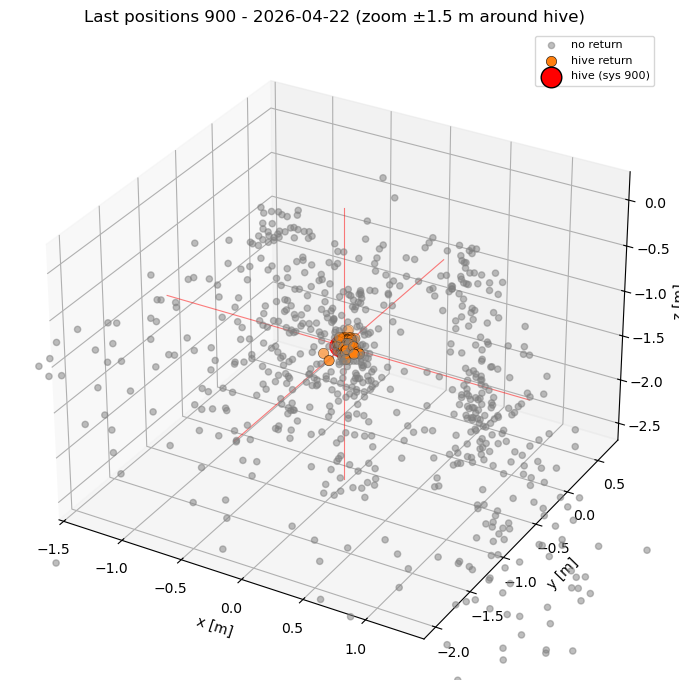

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

# -- Plot controls -----------------------------------------------------------
ZOOM_RADIUS    = 1.5    # axis half-width around the hive(s), in metres
OUTLIER_RADIUS = 5.0    # drop last-positions further than this from any hive
# ---------------------------------------------------------------------------

# Which hives are "in play" for this run.
if SPOT_SELECTION == "both":
    hives_to_show = [("hive (sys 900)", hive_900_pos),
                     ("hive (sys 939)", hive_939_pos)]
else:
    hives_to_show = [(f"hive (sys {SPOT_SELECTION})", HIVE_POS)]

hive_arr = np.stack([h for _, h in hives_to_show])   # (k, 3)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")

# ---- Scatter the last positions first (so the hive paints on top). --------
if not results.empty:
    res = results.dropna(subset=["last_x", "last_y", "last_z"]).copy()

    # Drop extreme outliers so the axes don't blow up.
    pts = res[["last_x", "last_y", "last_z"]].to_numpy(dtype=float)
    if len(pts):
        # distance from each point to its nearest hive
        d2 = np.min(np.linalg.norm(
            pts[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
        res = res[d2 <= OUTLIER_RADIUS]

    n_dropped = len(results) - len(res)
    if n_dropped:
        print(f"(plot) dropped {n_dropped} outlier last-position(s) "
              f"beyond {OUTLIER_RADIUS} m from any hive")

    ret  = res[res["hive_return"]]
    miss = res[~res["hive_return"]]
    ax.scatter(miss["last_x"], miss["last_y"], miss["last_z"],
               c="tab:gray", s=20, alpha=0.5, label="no return")
    ax.scatter(ret["last_x"],  ret["last_y"],  ret["last_z"],
               c="tab:orange", s=55, edgecolors="black", linewidths=0.4,
               label="hive return")

# ---- Now draw the hive(s) on top. -----------------------------------------
def plot_hive(ax, pos, tol, label, xlim, ylim, zlim):
    """Big red dot + wireframe sphere + crosshair lines through the hive."""
    # Crosshair lines: guaranteed visible no matter the view angle.
    ax.plot(xlim, [pos[1]] * 2, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, ylim, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, [pos[1]] * 2, zlim, c="red", lw=0.8, alpha=0.5)
    # Wireframe tolerance sphere.
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 12)
    xs = pos[0] + tol * np.outer(np.cos(u), np.sin(v))
    ys = pos[1] + tol * np.outer(np.sin(u), np.sin(v))
    zs = pos[2] + tol * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="red", alpha=0.6, linewidth=0.7)
    # The red dot itself.
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o",
               s=220, edgecolors="black", linewidths=1.0, label=label,
               depthshade=False)


# Zoom around the hive(s).
xlim = (hive_arr[:, 0].min() - ZOOM_RADIUS, hive_arr[:, 0].max() + ZOOM_RADIUS)
ylim = (hive_arr[:, 1].min() - ZOOM_RADIUS, hive_arr[:, 1].max() + ZOOM_RADIUS)
zlim = (hive_arr[:, 2].min() - ZOOM_RADIUS, hive_arr[:, 2].max() + ZOOM_RADIUS)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

for label, pos in hives_to_show:
    plot_hive(ax, pos, TOL, label, xlim, ylim, zlim)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"Last positions {SPOT_SELECTION} - {TARGET_DATE.date()} "
             f"(zoom ±{ZOOM_RADIUS} m around hive)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### 5. Hive exit classifier v1 (baseline)

Mirror of hive-return, but on the **first** valid sample of each track. A "hive exit" is any flight whose first valid `(x, y, z)` is within `TOL` metres (sphere) of the hive — i.e. the bee started *at* the hive and flew off.

Uses the same `HIVE_BY_SYSTEM` lookup so each track is compared to its own camera's hive.


In [21]:
# How many leading frames to scan. Same idea as TAIL_FRAMES: the tracker
# often starts a few frames AFTER the bee leaves the hive, so the very
# first sample alone is too strict.
HEAD_FRAMES = 10


def first_valid_xyz(trk):
    """First valid (x, y, z) of a track, or None."""
    xyz = valid_xyz(trk)
    return None if xyz is None else xyz[0]


def min_distance_from_hive_start(trk, hive):
    """Smallest Euclidean distance between the first HEAD_FRAMES valid samples
    and the hive position. np.inf if there are no valid samples."""
    xyz = valid_xyz(trk)
    if xyz is None:
        return float("inf")
    head = xyz[:HEAD_FRAMES]
    return float(np.min(np.linalg.norm(head - hive, axis=1)))


def is_hive_exit(trk, hive, tol=TOL):
    """True if the bee was within `tol` metres of the hive in the first
    HEAD_FRAMES valid samples."""
    return min_distance_from_hive_start(trk, hive) <= tol


rows = []
for uid, trk in tracks.items():
    hive = hive_for_uid(uid)
    xyz  = first_valid_xyz(trk)
    rows.append({
        "uid"           : uid,
        "system_id"     : uid_to_system.get(uid),
        "n_frames"      : len(trk),
        "first_x"       : None if xyz is None else xyz[0],
        "first_y"       : None if xyz is None else xyz[1],
        "first_z"       : None if xyz is None else xyz[2],
        "hive_x"        : hive[0],
        "hive_y"        : hive[1],
        "hive_z"        : hive[2],
        "min_dist_start": min_distance_from_hive_start(trk, hive),
        "hive_exit"     : is_hive_exit(trk, hive),
    })

exit_results = (pd.DataFrame(rows)
                .sort_values(["hive_exit", "min_dist_start"], ascending=[False, True])
                .reset_index(drop=True))
exit_results


,uid,system_id,n_frames,first_x,first_y,first_z,hive_x,hive_y,hive_z,min_dist_start,hive_exit
0,1483694,900,137,-0.017439,-0.642742,-1.17376,-0.04,-0.665,-1.195,0.015047,True
1,1482650,900,118,-0.048715,-0.661003,-1.18127,-0.04,-0.665,-1.195,0.016450,True
2,1483754,900,121,-0.036149,-0.663925,-1.17398,-0.04,-0.665,-1.195,0.017577,True
3,1481673,900,207,-0.030013,-0.660811,-1.18108,-0.04,-0.665,-1.195,0.017637,True
4,1482728,900,172,-0.047926,-0.650295,-1.16214,-0.04,-0.665,-1.195,0.018114,True
...,...,...,...,...,...,...,...,...,...,...,...
841,1491513,900,113,1.203110,-0.465091,-3.75482,-0.04,-0.665,-1.195,2.623458,False
842,1482052,900,130,1.902900,-0.533900,-3.11001,-0.04,-0.665,-1.195,2.656794,False
843,1485294,900,125,1.960500,-0.578132,-3.15914,-0.04,-0.665,-1.195,2.776136,False
844,1482322,900,174,1.999780,-0.609232,-3.25771,-0.04,-0.665,-1.195,2.824930,False


In [22]:
n_total = len(exit_results)
n_exit  = int(exit_results["hive_exit"].sum())
print(f"Hive exits on {TARGET_DATE.date()}: {n_exit} / {n_total} tracks")
if n_total:
    print(f"Exit rate: {n_exit / n_total:.1%}")


Hive exits on 2026-04-22: 96 / 846 tracks
Exit rate: 11.3%


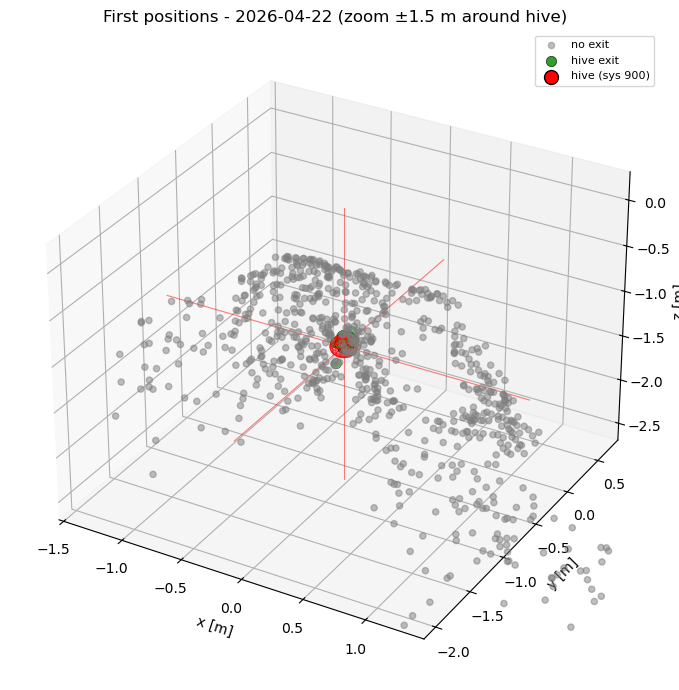

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Re-uses the same controls as the return plot.
ZOOM_RADIUS    = 1.5
OUTLIER_RADIUS = 5.0

if SPOT_SELECTION == "both":
    hives_to_show = [("hive (sys 900)", hive_900_pos),
                     ("hive (sys 939)", hive_939_pos)]
else:
    hives_to_show = [(f"hive (sys {SPOT_SELECTION})", HIVE_POS)]

hive_arr = np.stack([h for _, h in hives_to_show])

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")

if not exit_results.empty:
    res = exit_results.dropna(subset=["first_x", "first_y", "first_z"]).copy()
    pts = res[["first_x", "first_y", "first_z"]].to_numpy(dtype=float)
    if len(pts):
        d2 = np.min(np.linalg.norm(
            pts[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
        res = res[d2 <= OUTLIER_RADIUS]

    n_dropped = len(exit_results) - len(res)
    if n_dropped:
        print(f"(plot) dropped {n_dropped} outlier first-position(s) "
              f"beyond {OUTLIER_RADIUS} m from any hive")

    exited     = res[res["hive_exit"]]
    not_exited = res[~res["hive_exit"]]
    ax.scatter(not_exited["first_x"], not_exited["first_y"], not_exited["first_z"],
               c="tab:gray", s=20, alpha=0.5, label="no exit")
    ax.scatter(exited["first_x"], exited["first_y"], exited["first_z"],
               c="tab:green", s=55, edgecolors="black", linewidths=0.4,
               label="hive exit")


def plot_hive(ax, pos, tol, label, xlim, ylim, zlim):
    ax.plot(xlim, [pos[1]] * 2, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, ylim, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, [pos[1]] * 2, zlim, c="red", lw=0.8, alpha=0.5)
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 12)
    xs = pos[0] + tol * np.outer(np.cos(u), np.sin(v))
    ys = pos[1] + tol * np.outer(np.sin(u), np.sin(v))
    zs = pos[2] + tol * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="red", alpha=0.6, linewidth=0.7)
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o",
               s=100, edgecolors="black", linewidths=1.0, label=label,
               depthshade=False)


xlim = (hive_arr[:, 0].min() - ZOOM_RADIUS, hive_arr[:, 0].max() + ZOOM_RADIUS)
ylim = (hive_arr[:, 1].min() - ZOOM_RADIUS, hive_arr[:, 1].max() + ZOOM_RADIUS)
zlim = (hive_arr[:, 2].min() - ZOOM_RADIUS, hive_arr[:, 2].max() + ZOOM_RADIUS)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

for label, pos in hives_to_show:
    plot_hive(ax, pos, TOL, label, xlim, ylim, zlim)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"First positions - {TARGET_DATE.date()} "
             f"(zoom ±{ZOOM_RADIUS} m around hive)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### 6. Exit classifier v2 (velocity back-extrapolation)

`min_dist_start` doesn't separate real exits from fly-bys (no bimodal valley). Replacement: fit a velocity from the first few valid samples, extrapolate backward in time, and ask whether the line passes close to the hive in the past. This is scale-invariant - the bee can be 50 cm away on its first sample and still classify cleanly, as long as its initial trajectory points straight outward from the hive.

Rules:
- At least **HEAD_N** valid samples at the start.
- Initial speed must exceed **MIN_SPEED** (rejects hoverers / artefacts).
- The closest-approach point of the backward ray must lie **in the past** (negative `t_star`) - rejects bees flying *toward* the hive.
- `|t_star|` must be less than **MAX_LAG_S** - rejects physically absurd extrapolations.
- Closest-approach distance to the hive must be **<= EXIT_TOL_V2**.

Produces `exit_results_v2` parallel to `exit_results`. A confusion matrix and overlaid daily curves compare the two.


Exit v1 (min_dist_start <= TOL)   :   96
Exit v2 (velocity back-extrap.)   :   80
Returns (unchanged)               :  139
re_ratio v1 = 1.45
re_ratio v2 = 1.74  <- target ~1.0

v2 reason breakdown (all tracks):
reason
closest_in_future    496
too_far              173
slow                  84
ok                    80
too_much_lag          13

Confusion matrix (rows=v1, cols=v2):
v2     False  True 
v1                 
False    722     28
True      44     52


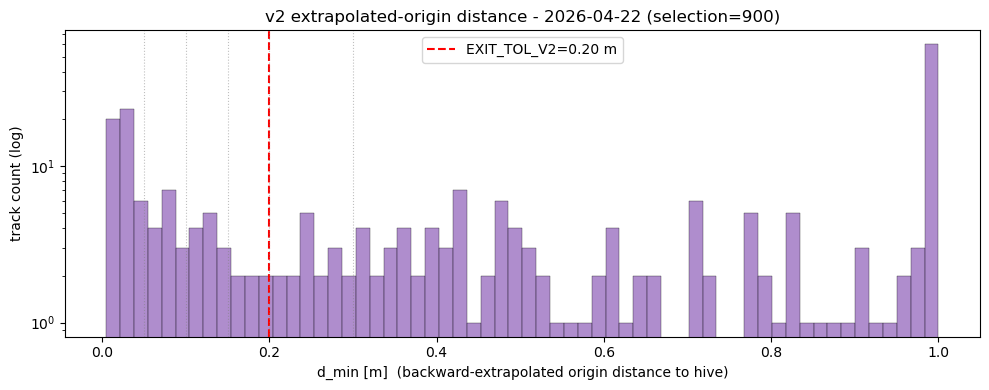

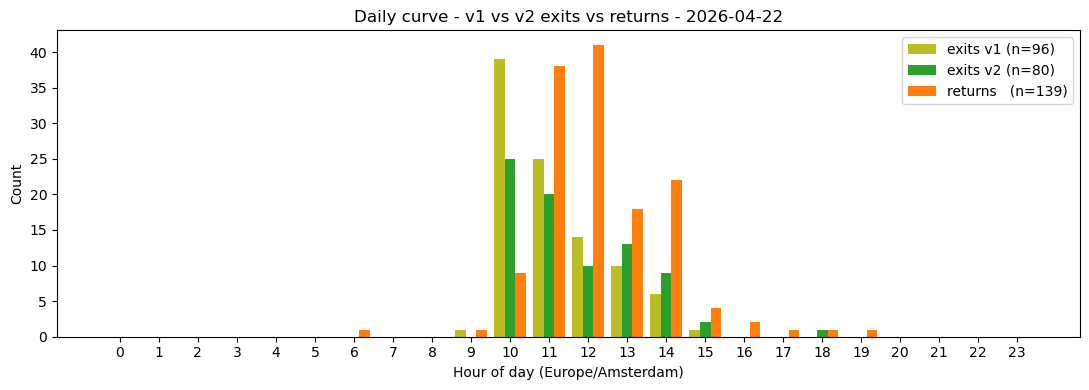

In [25]:
import matplotlib.pyplot as plt

# -- Controls --------------------------------------------------------------
HEAD_N       = 5        # samples used to fit initial velocity
EXIT_TOL_V2  = 0.20     # m  - tolerance on the back-extrapolated origin
MIN_SPEED    = 0.2      # m/s - reject slow / hovering tracks
MAX_LAG_S    = 2.0      # s   - reject implausible extrapolations
FPS          = 60.0     # PATS-C frame rate (fallback when no time column)
# -------------------------------------------------------------------------

def is_hive_exit_v2(trk, hive, head_n=HEAD_N, exit_tol=EXIT_TOL_V2,
                   min_speed=MIN_SPEED, max_lag_s=MAX_LAG_S, fps=FPS):
    """Back-extrapolate the first head_n valid samples and test whether the
    line passes within exit_tol of the hive in the recent past."""
    xyz = valid_xyz(trk)
    if xyz is None or len(xyz) < head_n:
        return False, {"reason": "short_track"}
    head = xyz[:head_n]
    p0   = head[0]

    # Linear fit per axis gives a robust velocity estimate.
    t = np.arange(head_n) / fps
    v = np.array([np.polyfit(t, head[:, k], 1)[0] for k in range(3)])
    speed = float(np.linalg.norm(v))
    if speed < min_speed:
        return False, {"reason": "slow", "speed_mps": speed}

    hive_np = np.asarray(hive, dtype=float)
    rel     = p0 - hive_np
    t_star  = -float(np.dot(v, rel)) / (speed ** 2)

    if t_star > 0:
        return False, {"reason": "closest_in_future",
                       "t_star_s": t_star, "speed_mps": speed}
    if abs(t_star) > max_lag_s:
        return False, {"reason": "too_much_lag",
                       "t_star_s": t_star, "speed_mps": speed}

    d_min = float(np.linalg.norm(p0 + v * t_star - hive_np))
    is_exit = d_min <= exit_tol
    return is_exit, {"t_star_s": t_star, "d_min_m": d_min,
                     "speed_mps": speed, "first_dist_m": float(np.linalg.norm(rel)),
                     "reason": "ok" if is_exit else "too_far"}

# -- Run classifier --------------------------------------------------------
ft_v2 = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft_v2.columns:
    ft_v2 = ft_v2[ft_v2["pos_valid_insect"] == 1]
sort_cols = ["detection_uid"]
for cand in ("rs_id", "time_insect", "timestamp"):
    if cand in ft_v2.columns:
        sort_cols.append(cand); break
ft_v2 = ft_v2.sort_values(sort_cols)

_det_sys = detections.set_index("uid")["system_id"]

rows = []
for uid_int, trk in ft_v2.groupby("detection_uid"):
    if "system_id" in trk.columns:
        sys_id = int(trk["system_id"].iloc[0])
    else:
        sys_id = int(_det_sys.get(int(uid_int), -1))
    if sys_id not in HIVE_BY_SYSTEM:
        continue
    hive = HIVE_BY_SYSTEM[sys_id]
    is_exit, diag = is_hive_exit_v2(trk, hive)
    rows.append({"uid": int(uid_int), "system_id": sys_id,
                 "hive_exit_v2": is_exit, **diag})

exit_results_v2 = pd.DataFrame(rows)

# -- Summary ---------------------------------------------------------------
n_v1 = int(exit_results["hive_exit"].sum())
n_v2 = int(exit_results_v2["hive_exit_v2"].sum())
n_ret = int(results["hive_return"].sum())

print(f"Exit v1 (min_dist_start <= TOL)   : {n_v1:4d}")
print(f"Exit v2 (velocity back-extrap.)   : {n_v2:4d}")
print(f"Returns (unchanged)               : {n_ret:4d}")
if n_v1 > 0:
    print(f"re_ratio v1 = {n_ret/n_v1:.2f}")
if n_v2 > 0:
    print(f"re_ratio v2 = {n_ret/n_v2:.2f}  <- target ~1.0")

# Reason breakdown for rejected tracks (v2).
print("\nv2 reason breakdown (all tracks):")
print(exit_results_v2["reason"].value_counts().to_string())

# -- Confusion matrix v1 vs v2 --------------------------------------------
compare = (exit_results[["uid", "hive_exit"]]
           .merge(exit_results_v2[["uid", "hive_exit_v2"]],
                  on="uid", how="outer"))
compare["hive_exit"]    = compare["hive_exit"].fillna(False)
compare["hive_exit_v2"] = compare["hive_exit_v2"].fillna(False)

ct = pd.crosstab(compare["hive_exit"], compare["hive_exit_v2"],
                 rownames=["v1"], colnames=["v2"])
print("\nConfusion matrix (rows=v1, cols=v2):")
print(ct.to_string())

# -- d_min_m histogram (v2 equivalent of the TOL diagnostic) --------------
dmin_ok = exit_results_v2.loc[exit_results_v2["d_min_m"].notna(), "d_min_m"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dmin_ok.clip(upper=1.0), bins=60, color="tab:purple",
        alpha=0.75, edgecolor="black", linewidth=0.3)
ax.axvline(EXIT_TOL_V2, color="red", linestyle="--",
           label=f"EXIT_TOL_V2={EXIT_TOL_V2:.2f} m")
for t in (0.05, 0.10, 0.15, 0.20, 0.30):
    ax.axvline(t, color="grey", ls=":", alpha=0.5, lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("d_min [m]  (backward-extrapolated origin distance to hive)")
ax.set_ylabel("track count (log)")
ax.set_title(f"v2 extrapolated-origin distance - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})")
ax.legend()
plt.tight_layout()
plt.show()

# -- Daily curve overlay: v1 vs v2 exits ----------------------------------
# Build a per-uid timestamp lookup.
_ts = pd.to_datetime(detections["datetime"],
                     format="%Y%m%d_%H%M%S", errors="coerce")
_ts = pd.DataFrame({"uid": detections["uid"], "ts": _ts})
_ts = _ts.dropna().drop_duplicates("uid")

def _hourly(flagged_uids):
    s = _ts[_ts["uid"].isin(flagged_uids)]["ts"]
    return s.dt.hour.value_counts().reindex(range(24), fill_value=0)

uids_v1 = exit_results.loc[exit_results["hive_exit"],     "uid"]
uids_v2 = exit_results_v2.loc[exit_results_v2["hive_exit_v2"], "uid"]
uids_r  = results.loc[results["hive_return"], "uid"]

hv1 = _hourly(uids_v1)
hv2 = _hourly(uids_v2)
hr  = _hourly(uids_r)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(24); w = 0.28
ax.bar(x - w, hv1.values, width=w, color="tab:olive",
       label=f"exits v1 (n={int(hv1.sum())})")
ax.bar(x,     hv2.values, width=w, color="tab:green",
       label=f"exits v2 (n={int(hv2.sum())})")
ax.bar(x + w, hr.values,  width=w, color="tab:orange",
       label=f"returns   (n={int(hr.sum())})")
ax.set_xticks(x)
ax.set_xlabel("Hour of day (Europe/Amsterdam)")
ax.set_ylabel("Count")
ax.set_title(f"Daily curve - v1 vs v2 exits vs returns "
             f"- {TARGET_DATE.date()}")
ax.legend()
plt.tight_layout()
plt.show()


### 7. Exit classifier v3 (hybrid) + re-derived indicators

`v1` over-counts (flags hoverers/returns whose first sample happens to sit near the hive). `v2` under-counts (kills real exits when the initial velocity is jittery). A naive union inherits v1's false positives. This hybrid uses v2 as the primary signal but lets v1 rescue tracks that v2 could not confidently classify - never the ones v2 actively rejects on geometric grounds.

**Rule**
```
hive_exit_v3 = hive_exit_v2  OR  (hive_exit  AND  v2_reason in {"slow", "short_track"})
```

`"closest_in_future"`, `"too_far"`, `"too_much_lag"` are **strong** rejections (the trajectory evidence says this is not an exit). We trust those and never let v1 overrule. `"slow"` and `"short_track"` are **weak** rejections (v2 had no data to form an opinion). On those, v1's first-sample-near-hive heuristic gets the benefit of the doubt.

The rest of this cell: build `hive_exit_v3`, summarise how the three classifiers compare, and re-derive re_ratio + trip_duration + daily_curve using v3 so you can see the effect downstream.


Counts (selection='900', date=2026-04-22)
  v1 exits          :   96
  v2 exits          :   80
  v3 (hybrid)       :  115
  returns           :  139

  re_ratio v1       : 1.45
  re_ratio v2       : 1.74
  re_ratio v3       : 1.21  <- target ~1.0

Hybrid composition:
  from v2 directly          : 80
  rescued via v1 (weak v2)  : 35
  rescue reasons breakdown  :
reason
slow    35

Trip duration v3          : n_matched=115  median=1955.0s  mean=1734.9s  p95=3202.6s


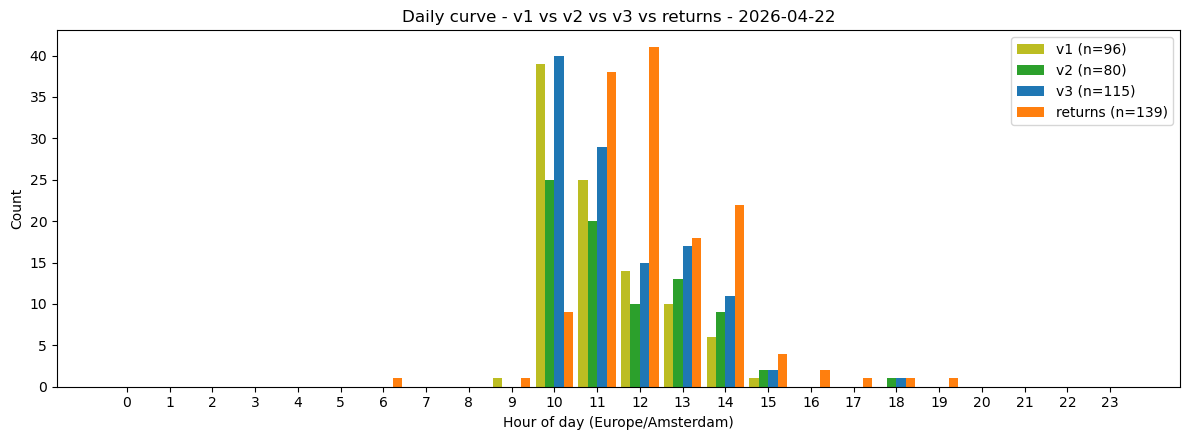

In [27]:
import matplotlib.pyplot as plt

STRONG_NO = {"closest_in_future", "too_far", "too_much_lag"}
WEAK_NO   = {"slow", "short_track"}

# --- 1. Build per-uid frame with v1 / v2 flag + v2 reason -----------------
merged = (exit_results[["uid", "hive_exit"]]
          .merge(exit_results_v2[["uid", "hive_exit_v2", "reason"]],
                 on="uid", how="outer"))
merged["hive_exit"]    = merged["hive_exit"].fillna(False).astype(bool)
merged["hive_exit_v2"] = merged["hive_exit_v2"].fillna(False).astype(bool)
merged["reason"]       = merged["reason"].fillna("no_v2")

# --- 2. Hybrid v3 ---------------------------------------------------------
rescue = merged["hive_exit"] & merged["reason"].isin(WEAK_NO | {"no_v2"})
merged["hive_exit_v3"] = merged["hive_exit_v2"] | rescue

# Promote to a standalone DataFrame so downstream code can use it.
exit_results_v3 = merged[["uid", "hive_exit_v3"]].copy()

# --- 3. Summary -----------------------------------------------------------
n_v1 = int(merged["hive_exit"].sum())
n_v2 = int(merged["hive_exit_v2"].sum())
n_v3 = int(merged["hive_exit_v3"].sum())
n_ret = int(results["hive_return"].sum())

print("Counts (selection="  f"{SPOT_SELECTION!r}, date={TARGET_DATE.date()})")
print(f"  v1 exits          : {n_v1:4d}")
print(f"  v2 exits          : {n_v2:4d}")
print(f"  v3 (hybrid)       : {n_v3:4d}")
print(f"  returns           : {n_ret:4d}")
print()
print(f"  re_ratio v1       : {n_ret/n_v1:.2f}" if n_v1 else "  re_ratio v1 : n/a")
print(f"  re_ratio v2       : {n_ret/n_v2:.2f}" if n_v2 else "  re_ratio v2 : n/a")
print(f"  re_ratio v3       : {n_ret/n_v3:.2f}  <- target ~1.0" if n_v3 else "  re_ratio v3 : n/a")

# How was v3 built?
rescued = int(rescue.sum())
print(f"\nHybrid composition:")
print(f"  from v2 directly          : {n_v2}")
print(f"  rescued via v1 (weak v2)  : {rescued}")
print(f"  rescue reasons breakdown  :")
print(merged.loc[rescue, "reason"].value_counts().to_string())

# --- 4. Re-derived indicators with v3 -------------------------------------
# One table: one row per uid with timestamp + the chosen exit flag + return flag.
_meta = detections[["uid", "datetime", "system_id"]].copy()
_meta["ts"] = pd.to_datetime(_meta["datetime"],
                             format="%Y%m%d_%H%M%S", errors="coerce")

events = (_meta
          .merge(results[["uid", "hive_return"]],   on="uid", how="left")
          .merge(exit_results_v3[["uid", "hive_exit_v3"]], on="uid", how="left"))
events["hive_return"]  = events["hive_return"].fillna(False)
events["hive_exit_v3"] = events["hive_exit_v3"].fillna(False)

# Trip duration (greedy per-camera match) using v3 exits.
_ex  = events[events["hive_exit_v3"] == True].sort_values("ts")
_rt  = events[events["hive_return"]   == True].sort_values("ts")
trip_rows = []
for sys_id in sorted(events["system_id"].dropna().unique()):
    g_ex = _ex[_ex["system_id"] == sys_id]
    g_rt = _rt[_rt["system_id"] == sys_id]
    used = set()
    for _, ex in g_ex.iterrows():
        cand = g_rt[(g_rt["ts"] > ex["ts"]) & (~g_rt["uid"].isin(used))]
        if cand.empty: continue
        rt = cand.iloc[0]
        trip_rows.append({"trip_seconds": (rt["ts"] - ex["ts"]).total_seconds()})
        used.add(rt["uid"])
trips_v3 = pd.DataFrame(trip_rows)
if not trips_v3.empty:
    s = trips_v3["trip_seconds"]
    print(f"\nTrip duration v3          : n_matched={len(trips_v3)}  "
          f"median={s.median():.1f}s  mean={s.mean():.1f}s  "
          f"p95={s.quantile(0.95):.1f}s")

# --- 5. Overlay daily curves: v1 / v2 / v3 exits + returns ----------------
def _hourly(uids):
    s = _meta[_meta["uid"].isin(uids)]["ts"]
    return s.dt.hour.value_counts().reindex(range(24), fill_value=0)

uids_v1 = exit_results.loc[exit_results["hive_exit"], "uid"]
uids_v2 = exit_results_v2.loc[exit_results_v2["hive_exit_v2"], "uid"]
uids_v3 = exit_results_v3.loc[exit_results_v3["hive_exit_v3"], "uid"]
uids_r  = results.loc[results["hive_return"], "uid"]

h1, h2, h3, hr = _hourly(uids_v1), _hourly(uids_v2), _hourly(uids_v3), _hourly(uids_r)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(24); w = 0.22
ax.bar(x - 1.5*w, h1.values, width=w, color="tab:olive",  label=f"v1 (n={int(h1.sum())})")
ax.bar(x - 0.5*w, h2.values, width=w, color="tab:green",  label=f"v2 (n={int(h2.sum())})")
ax.bar(x + 0.5*w, h3.values, width=w, color="tab:blue",   label=f"v3 (n={int(h3.sum())})")
ax.bar(x + 1.5*w, hr.values, width=w, color="tab:orange", label=f"returns (n={int(hr.sum())})")
ax.set_xticks(x)
ax.set_xlabel("Hour of day (Europe/Amsterdam)")
ax.set_ylabel("Count")
ax.set_title(f"Daily curve - v1 vs v2 vs v3 vs returns - {TARGET_DATE.date()}")
ax.legend()
plt.tight_layout()
plt.show()


### 8. Activate v3 as the default classifier

The sweep (section 14) confirmed v3 is the stable one. This cell promotes it to **THE** exit classifier: every downstream indicator that reads `exit_results["hive_exit"]` now sees v3's answers instead of v1's. No other cell needs to change.

**What happens**
- v1's original output is preserved under `exit_results_v1` (so we can still diff).
- `exit_results` is overwritten to point at v3, with the column renamed from `hive_exit_v3` back to `hive_exit`. That's the column name the rest of the notebook expects.
- Re-run sections 6 (foraging indicators) and 7 (summary) after this cell and you'll see v3 numbers everywhere.

**Using on new data.** When you download a new day, run the notebook top-to-bottom. Sections 11 and 13 rebuild `exit_results_v2` / `exit_results_v3`, this cell re-points `exit_results` at v3, and the indicators update automatically. If you ever want to A/B against v1, just load `exit_results_v1` — it's still there.


In [ ]:
# --- Preserve v1 ---------------------------------------------------------
exit_results_v1 = exit_results.copy()

# --- Promote v3 to the canonical exit_results ---------------------------
exit_results = (exit_results_v3[["uid", "hive_exit_v3"]]
                .rename(columns={"hive_exit_v3": "hive_exit"})
                .copy())

print(f"Active classifier: v3")
print(f"  exit_results     : {len(exit_results)} rows, "
      f"{int(exit_results['hive_exit'].sum())} exits")
print(f"  exit_results_v1  : {len(exit_results_v1)} rows, "
      f"{int(exit_results_v1['hive_exit'].sum())} exits (kept for reference)")
print()
print("Re-run sections 6 (foraging indicators) and 7 (summary) to see v3 numbers.")


### 9. Save results to `EXPORT_DIR`

Permanent copies of the four key result tables, written to `EXPORT_DIR`. This cell runs **after** v3 has been activated, so `hive_exit_results.csv` holds v3's output - the classifier we've chosen to trust.

Files written:

- `detections.csv` - one row per flight detection.
- `flight_tracks.csv` - all per-frame XYZ positions concatenated, with `detection_uid` + `system_id`.
- `hive_return_results.csv` - per-uid return classification (from section 3).
- `hive_exit_results.csv` - per-uid exit classification (v3, active).

Safe to commit-ignore; see `.gitignore`.


In [ ]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Detection summaries
detections.to_csv(EXPORT_DIR / "detections.csv", index=False)

# 2. All flight tracks concatenated, with a detection_uid column linking back
if tracks:
    track_frames = []
    for uid, trk in tracks.items():
        t = trk.copy()
        t["detection_uid"] = uid
        # propagate the camera id so we can filter per sensor later
        sysids = detections.loc[detections["uid"] == uid, "system_id"]
        t["system_id"] = sysids.iloc[0] if len(sysids) else None
        track_frames.append(t)
    all_tracks = pd.concat(track_frames, ignore_index=True)
    all_tracks.to_csv(EXPORT_DIR / "flight_tracks.csv", index=False)
else:
    all_tracks = pd.DataFrame()
    print("No non-empty tracks to export.")

# 3. Hive-return classification
results.to_csv(EXPORT_DIR / "hive_return_results.csv", index=False)

# 4. Hive-exit classification (v3 = the currently active classifier)
exit_results.to_csv(EXPORT_DIR / "hive_exit_results.csv", index=False)

print(f"Wrote to {EXPORT_DIR.resolve()}:")
for f in sorted(EXPORT_DIR.iterdir()):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:,.1f} KB)")


### 10. Foraging sub-indicators (re_ratio / trip_duration / daily_curve)

In this paragraph the sub indicators such as re_ratio, exit_return_count, trip_duration, daily_curve will be generated. Based on the values found in chapter 3 and 6.

exit_return_count  : exits=96  returns=139  (tracks=846)
re_ratio           : 1.448
trip_duration      : 96 matched  (unmatched exits=0, unmatched returns=43)
                   : median=2119.0s  mean=1752.9s  p95=2968.2s  max=4652.0s


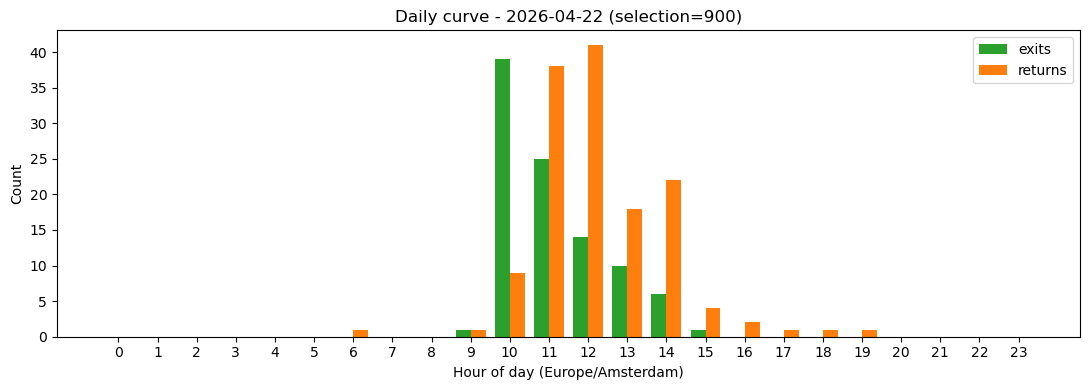

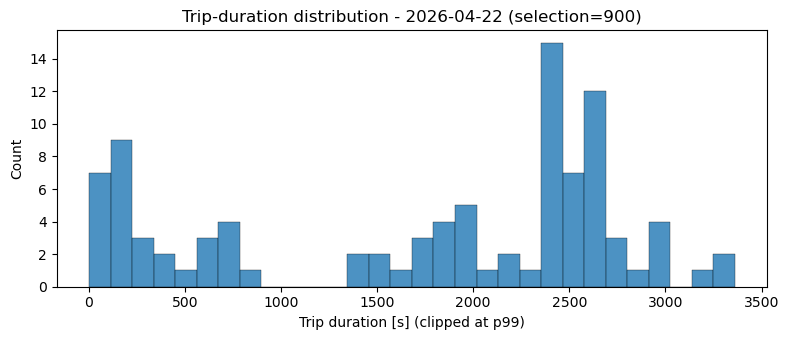

In [24]:
import matplotlib.pyplot as plt

# --- Assemble one table: one row per uid with timestamp + both labels ------
_meta = detections[["uid", "datetime", "start_datetime", "system_id"]].copy()
_meta["ts"] = pd.to_datetime(_meta["datetime"],
                             format="%Y%m%d_%H%M%S", errors="coerce")

_ret_flag  = results[["uid", "hive_return"]]
_ext_flag  = exit_results[["uid", "hive_exit"]]

events = (_meta.merge(_ret_flag, on="uid", how="left")
               .merge(_ext_flag, on="uid", how="left"))


# 1. exit_return_count
# -------------------------------------------------------------------------
n_exits   = int(events["hive_exit"].fillna(False).sum())
n_returns = int(events["hive_return"].fillna(False).sum())
print(f"exit_return_count  : exits={n_exits}  returns={n_returns}"
      f"  (tracks={len(events)})")


# 2. re_ratio = returns / exits
# -------------------------------------------------------------------------
re_ratio = (n_returns / n_exits) if n_exits > 0 else float("nan")
print(f"re_ratio           : {re_ratio:.3f}")


# 3. trip_duration  (match every exit to the next unused return on the
#    same camera)
# -------------------------------------------------------------------------
_exits_df  = events[events["hive_exit"]   == True].sort_values("ts")
_returns_df = events[events["hive_return"] == True].sort_values("ts")

trip_rows = []
for sys_id in sorted(events["system_id"].dropna().unique()):
    g_ex = _exits_df[_exits_df["system_id"]  == sys_id]
    g_rt = _returns_df[_returns_df["system_id"] == sys_id].copy()
    used = set()
    for _, ex in g_ex.iterrows():
        cand = g_rt[(g_rt["ts"] > ex["ts"]) & (~g_rt["uid"].isin(used))]
        if cand.empty:
            continue
        rt = cand.iloc[0]
        trip_rows.append({
            "system_id"    : int(sys_id),
            "exit_uid"     : int(ex["uid"]),
            "return_uid"   : int(rt["uid"]),
            "exit_ts"      : ex["ts"],
            "return_ts"    : rt["ts"],
            "trip_seconds" : (rt["ts"] - ex["ts"]).total_seconds(),
        })
        used.add(rt["uid"])

trips = pd.DataFrame(trip_rows)
n_unmatched_exits   = n_exits   - len(trips)
n_unmatched_returns = n_returns - len(trips)

print(f"trip_duration      : {len(trips)} matched  "
      f"(unmatched exits={n_unmatched_exits}, "
      f"unmatched returns={n_unmatched_returns})")
if not trips.empty:
    s = trips["trip_seconds"]
    print(f"                   : median={s.median():.1f}s  "
          f"mean={s.mean():.1f}s  p95={s.quantile(0.95):.1f}s  "
          f"max={s.max():.1f}s")


# 4. daily_curve (per-hour counts, local time)
# -------------------------------------------------------------------------
events["hour"] = events["ts"].dt.hour
hours = list(range(24))

exits_by_h   = (events[events["hive_exit"]   == True]
                .groupby("hour").size().reindex(hours, fill_value=0))
returns_by_h = (events[events["hive_return"] == True]
                .groupby("hour").size().reindex(hours, fill_value=0))

daily_curve = pd.DataFrame({"exits": exits_by_h, "returns": returns_by_h})


# Plot: daily curve
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(24)
w = 0.38
ax.bar(x - w/2, daily_curve["exits"].values,   width=w,
       label="exits",   color="tab:green")
ax.bar(x + w/2, daily_curve["returns"].values, width=w,
       label="returns", color="tab:orange")
ax.set_xticks(x)
ax.set_xlabel("Hour of day (Europe/Amsterdam)")
ax.set_ylabel("Count")
ax.set_title(f"Daily curve - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})")
ax.legend()
plt.tight_layout()
plt.show()


# Optional: plot trip-duration histogram (only if we have matched trips)
# -------------------------------------------------------------------------
if not trips.empty:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(trips["trip_seconds"].clip(upper=trips["trip_seconds"].quantile(0.99)),
            bins=30, color="tab:blue", alpha=0.8, edgecolor="black", linewidth=0.3)
    ax.set_xlabel("Trip duration [s] (clipped at p99)")
    ax.set_ylabel("Count")
    ax.set_title(f"Trip-duration distribution - {TARGET_DATE.date()} (selection={SPOT_SELECTION})")
    plt.tight_layout()
    plt.show()


### 11. Sanity check: show 20 hive exits

Prints the top 20 tracks flagged as a hive exit (closest first-sample to the hive, so the "best" candidates) with their datetime, trajectory distance and mean velocity. Paste any datetime into the PATS web interface to look up the video.


In [112]:
N = 20

# Join exit_results with the detection metadata to get datetime / dist_traject / vel_mean.
_exits = exit_results[exit_results["hive_exit"]].copy()

_cols_from_det = ["uid", "datetime", "start_datetime", "dist_traject", "vel_mean","size"]
_have = [c for c in _cols_from_det if c in detections.columns]
_det  = detections[_have].drop_duplicates("uid")

_sample = (_exits.merge(_det, on="uid", how="left")
                 .sort_values("min_dist_start")
                 .head(N))

show_cols = [c for c in
             ["uid", "datetime", "system_id", "min_dist_start",
              "dist_traject", "vel_mean", "size"]
             if c in _sample.columns]

_sample["size"] = _sample["size"]*1000

_sample = _sample[show_cols].rename(columns={
    "min_dist_start": "dist_to_hive_start [m]",
    "dist_traject"  : "dist_trajectory [m]",
    "vel_mean"      : "vel_mean [m/s]",
    "size"          : "size [mm]",
})


print(f"Top {len(_sample)} hive exits on {TARGET_DATE.date()} "
      f"(closest first-sample to hive first):\n")
print(_sample.to_string(index=False))


Top 20 hive exits on 2026-04-19 (closest first-sample to hive first):

    uid        datetime  system_id  dist_to_hive_start [m]  dist_trajectory [m]  vel_mean [m/s]  size [mm]
1329273 20260419_114022        900                0.008408             1.024797        0.570700  10.885323
1335506 20260419_141201        900                0.008793             0.990629        0.427421  10.329262
1335803 20260419_141954        900                0.011191             2.438987        0.273285   9.218192
1333595 20260419_132206        900                0.011776             1.877744        1.294995  11.733060
1331957 20260419_124041        900                0.013428             3.797602        0.364036   9.353968
1332513 20260419_124959        900                0.015405             1.374035        0.673595   9.744206
1335087 20260419_135308        900                0.016930             1.420112        1.031227  12.083083
1330545 20260419_121410        900                0.018288             0.

### 12. Full-track sanity check

Load `flight_tracks.csv` (the one exported in section 5) and draw N random flights as 3D lines, each with:
- green ● at the start (first valid sample)
- orange ● at the end (last valid sample)
- hive + TOL sphere in red

Flip `TRACK_SET` between `"exits"`, `"returns"`, or `"all"` to restrict the sample. Flip `RANDOM` off to get the top-N closest-to-hive candidates instead of a uniform sample.


Plotting 20 exits track(s) (RANDOM=True)


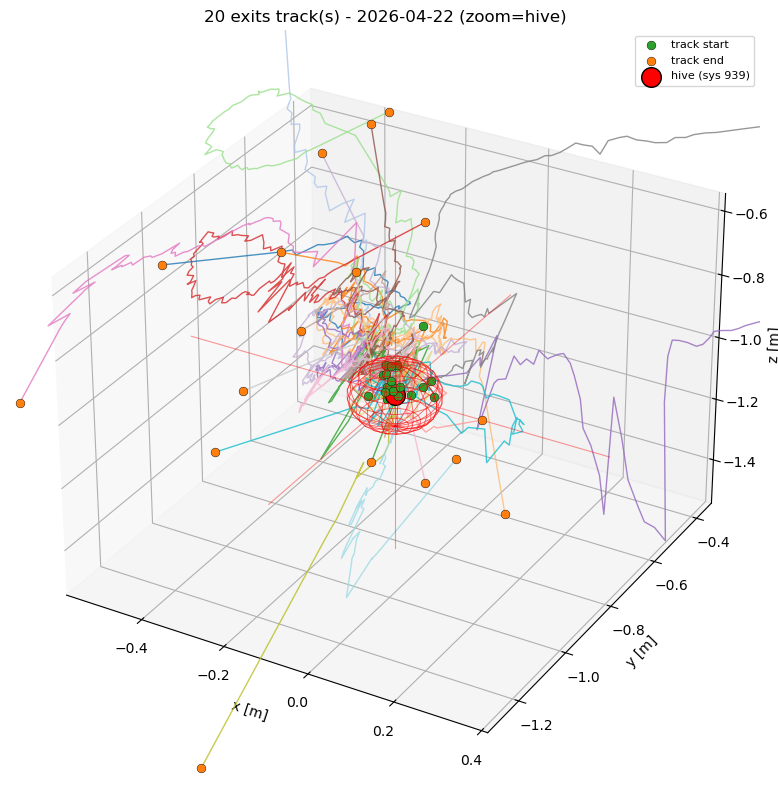

In [94]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -- Controls ---------------------------------------------------------------
N            = 20
TRACK_SET    = "exits"     # "exits" | "returns" | "all"
RANDOM       = True        # False = take the best (lowest min-distance) ones
RANDOM_SEED  = 0

# Zoom mode:
#   "auto"   -> fit axes to the actual plotted tracks (+ PADDING)
#   "hive"   -> ZOOM_RADIUS box around the hive(s)
ZOOM_MODE    = "hive"
PADDING      = 0.05        # metres of slack around the track bounding box
ZOOM_RADIUS  = 0.5         # used only when ZOOM_MODE == "hive"

# Safety clip: ignore samples further than this from the hive when
# auto-fitting, so one glitchy point doesn't ruin the view.
CLIP_RADIUS  = 3.0
# ---------------------------------------------------------------------------

# 1. Load the exported flight tracks.
tracks_csv = EXPORT_DIR / "flight_tracks.csv"
if not tracks_csv.exists():
    raise FileNotFoundError(
        f"{tracks_csv} not found - run the export cell first."
    )
ft = pd.read_csv(tracks_csv)
if "pos_valid_insect" in ft.columns:
    ft = ft[ft["pos_valid_insect"] == 1]

# 2. Pick which uids to plot.
if TRACK_SET == "exits":
    pool = exit_results[exit_results["hive_exit"]].copy()
    score_col = "min_dist_start"
elif TRACK_SET == "returns":
    pool = results[results["hive_return"]].copy()
    score_col = "min_dist_hive"
elif TRACK_SET == "all":
    pool = results.copy()
    score_col = "min_dist_hive"
else:
    raise ValueError(f"Unknown TRACK_SET={TRACK_SET!r}")

if pool.empty:
    raise RuntimeError(f"No tracks in pool (TRACK_SET={TRACK_SET!r}).")

if RANDOM:
    sample = pool.sample(n=min(N, len(pool)), random_state=RANDOM_SEED)
else:
    sample = pool.sort_values(score_col).head(N)

uids = sample["uid"].astype(int).tolist()
print(f"Plotting {len(uids)} {TRACK_SET} track(s) (RANDOM={RANDOM})")

# 3. Which hives to draw.
if SPOT_SELECTION == "both":
    hives_to_show = [("hive (sys 900)", hive_900_pos),
                     ("hive (sys 939)", hive_939_pos)]
else:
    hives_to_show = [(f"hive (sys {SPOT_SELECTION})", HIVE_POS)]
hive_arr = np.stack([h for _, h in hives_to_show])

# 4. Plot.
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")

cmap = plt.get_cmap("tab20")
lines_added = 0
plotted_points = []            # collect xyz of everything actually drawn

for idx, uid in enumerate(uids):
    trk = ft[ft["detection_uid"] == uid]
    if trk.empty:
        print(f"  uid={uid}: no rows in flight_tracks.csv - skipped")
        continue
    x = trk["posX_insect"].to_numpy(dtype=float)
    y = trk["posY_insect"].to_numpy(dtype=float)
    z = trk["posZ_insect"].to_numpy(dtype=float)

    # For auto-fitting: drop samples far from any hive so one glitch point
    # doesn't stretch the box to infinity.
    pts = np.stack([x, y, z], axis=1)
    dists = np.min(np.linalg.norm(
        pts[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
    keep = dists <= CLIP_RADIUS
    plotted_points.append(pts[keep])

    color = cmap(idx % 20)
    ax.plot(x, y, z, color=color, lw=1.0, alpha=0.8)
    ax.scatter(x[0],  y[0],  z[0],  color="tab:green",  s=40,
               edgecolors="black", linewidths=0.3,
               label="track start" if lines_added == 0 else None)
    ax.scatter(x[-1], y[-1], z[-1], color="tab:orange", s=40,
               edgecolors="black", linewidths=0.3,
               label="track end" if lines_added == 0 else None)
    lines_added += 1

# 5. Decide axis limits.
if ZOOM_MODE == "hive":
    xlim = (hive_arr[:, 0].min() - ZOOM_RADIUS, hive_arr[:, 0].max() + ZOOM_RADIUS)
    ylim = (hive_arr[:, 1].min() - ZOOM_RADIUS, hive_arr[:, 1].max() + ZOOM_RADIUS)
    zlim = (hive_arr[:, 2].min() - ZOOM_RADIUS, hive_arr[:, 2].max() + ZOOM_RADIUS)
else:  # "auto"
    all_pts = np.concatenate(plotted_points) if plotted_points else hive_arr
    all_pts = np.vstack([all_pts, hive_arr])    # always include hive(s)
    lo = all_pts.min(axis=0) - PADDING
    hi = all_pts.max(axis=0) + PADDING
    xlim = (lo[0], hi[0]); ylim = (lo[1], hi[1]); zlim = (lo[2], hi[2])

ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)

# 6. Draw hive(s) on top.
def _plot_hive(ax, pos, tol, label, xlim, ylim, zlim):
    ax.plot(xlim, [pos[1]] * 2, [pos[2]] * 2, c="red", lw=0.8, alpha=0.4)
    ax.plot([pos[0]] * 2, ylim, [pos[2]] * 2, c="red", lw=0.8, alpha=0.4)
    ax.plot([pos[0]] * 2, [pos[1]] * 2, zlim, c="red", lw=0.8, alpha=0.4)
    u = np.linspace(0, 2 * np.pi, 20); v = np.linspace(0, np.pi, 12)
    xs = pos[0] + tol * np.outer(np.cos(u), np.sin(v))
    ys = pos[1] + tol * np.outer(np.sin(u), np.sin(v))
    zs = pos[2] + tol * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="red", alpha=0.6, linewidth=0.6)
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o",
               s=200, edgecolors="black", linewidths=1.0, label=label,
               depthshade=False)

for lbl, pos in hives_to_show:
    _plot_hive(ax, pos, TOL, lbl, xlim, ylim, zlim)

ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title(f"{len(uids)} {TRACK_SET} track(s) - {TARGET_DATE.date()} "
             f"(zoom={ZOOM_MODE})")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### 13. Flight geometry sub-indicators

Three geometry-derived features per track, aggregated over the day:

- **Path tortuosity** - `arc_length / end_to_end_displacement`. `1.0` = perfect straight line (directed transit); higher = winding (searching, hovering). Cleanest proxy for "foraging vs. transiting."
- **Exit heading** - in the top-down (x, y) plane, the vector from the hive to the first track sample `>= REF_DIST` m away. Converted to azimuth and shown as a rose plot per camera.
- **Return heading** - azimuth of the first valid sample of a return track (where the bee entered the frame), relative to the hive. Tells you which direction the bees are foraging *from*.

**Reference frame.** Both headings are rotated so that the hive entrance faces **0 degrees** and go clockwise like a compass (0 = straight out of the entrance; 90 = right of the entrance when you're inside the hive looking out; etc.). Each camera needs its entrance direction configured in `HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM` below - the exit rose plot is the calibration tool: rotate the entrance-azimuth until the exit bulge sits at 0 degrees.


In [ ]:
import matplotlib.pyplot as plt

# -- Controls ---------------------------------------------------------------
REF_DIST   = 0.30   # m - for exit heading, first sample at least this far from hive
N_BINS     = 24     # rose plot bins (15 deg each)
TORT_CLIP  = 5.0    # tortuosity histogram x-axis clip

# Entrance direction per camera, in degrees CCW from the camera's +x axis.
# EDIT these after looking at the exit rose plot: rotate the value until the
# exit bulge sits at 0 degrees on the rose.
HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM = {
    900: 0.0,
    939: 0.0,
}
# ---------------------------------------------------------------------------

# 1. Load tracks.
ft = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft.columns:
    ft = ft[ft["pos_valid_insect"] == 1]
sort_cols = ["detection_uid"]
for cand in ("rs_id", "time_insect", "timestamp"):
    if cand in ft.columns:
        sort_cols.append(cand); break
ft = ft.sort_values(sort_cols)

# Quick lookups for flags.
ret_flags = results.set_index("uid")["hive_return"]
ext_flags = exit_results.set_index("uid")["hive_exit"]

# 2. Per-track geometry + headings in one pass.
tort_rows       = []
exit_headings   = []   # list of (sys_id, azimuth_rad_entrance_relative)
return_headings = []

for uid, trk in ft.groupby("detection_uid"):
    xyz = trk[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(float)
    if len(xyz) < 2:
        continue
    if "system_id" not in trk.columns:
        continue
    sys_id = int(trk["system_id"].iloc[0])
    if sys_id not in HIVE_BY_SYSTEM:
        continue
    hive = np.asarray(HIVE_BY_SYSTEM[sys_id])
    entrance_az = HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM.get(sys_id, 0.0)

    # Tortuosity.
    arc  = float(np.linalg.norm(np.diff(xyz, axis=0), axis=1).sum())
    disp = float(np.linalg.norm(xyz[-1] - xyz[0]))
    tort = arc / disp if disp > 1e-6 else np.nan

    is_exit   = bool(ext_flags.get(int(uid), False))
    is_return = bool(ret_flags.get(int(uid), False))

    tort_rows.append({"uid": int(uid), "system_id": sys_id,
                      "arc_m": arc, "displacement_m": disp, "tortuosity": tort,
                      "hive_exit": is_exit, "hive_return": is_return})

    # Exit heading: first sample in the (x, y) plane at >= REF_DIST from hive.
    if is_exit:
        dists_xy = np.linalg.norm(xyz[:, :2] - hive[:2], axis=1)
        idx = np.where(dists_xy >= REF_DIST)[0]
        if len(idx):
            p_xy = xyz[idx[0], :2]
            az = np.arctan2(p_xy[1] - hive[1], p_xy[0] - hive[0])
            az = (az - np.deg2rad(entrance_az)) % (2 * np.pi)
            exit_headings.append((sys_id, az))

    # Return heading: first valid sample of the track (where bee entered frame).
    if is_return:
        p_xy = xyz[0, :2]
        az = np.arctan2(p_xy[1] - hive[1], p_xy[0] - hive[0])
        az = (az - np.deg2rad(entrance_az)) % (2 * np.pi)
        return_headings.append((sys_id, az))

tort_df = pd.DataFrame(tort_rows)

print(f"tracks analysed : {len(tort_df)}")
print(f"exit headings   : {len(exit_headings)}")
print(f"return headings : {len(return_headings)}")
if not tort_df.empty:
    for mask, label in [(tort_df["hive_exit"],   "exits  "),
                        (tort_df["hive_return"], "returns"),
                        (slice(None),            "all    ")]:
        vals = tort_df.loc[mask, "tortuosity"].dropna()
        if not len(vals):
            continue
        print(f"tortuosity {label} : n={len(vals):4d}  "
              f"median={vals.median():5.2f}  "
              f"p75={vals.quantile(0.75):5.2f}  "
              f"p95={vals.quantile(0.95):5.2f}")

# 3. Tortuosity histogram (exits + returns overlaid).
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(1.0, TORT_CLIP, 41)
for label, mask, color in [
    ("exits",   tort_df["hive_exit"],    "tab:green"),
    ("returns", tort_df["hive_return"],  "tab:orange"),
]:
    vals = tort_df.loc[mask, "tortuosity"].dropna().clip(upper=TORT_CLIP)
    if vals.empty:
        continue
    ax.hist(vals, bins=bins, alpha=0.55, color=color,
            label=f"{label} (n={len(vals)}, median={vals.median():.2f})",
            edgecolor="black", linewidth=0.3)
ax.axvline(1.0, color="black", ls="--", alpha=0.5,
           label="straight line")
ax.set_xlabel("Path tortuosity  (arc length / straight-line displacement)")
ax.set_ylabel("Count")
ax.set_title(f"Path tortuosity - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})")
ax.legend()
plt.tight_layout()
plt.show()

# 4. Rose plots per system_id.
def _rose(ax, angles_rad, title, color):
    if len(angles_rad) == 0:
        ax.set_title(f"{title}\n(no data)")
        return
    bins_theta = np.linspace(0, 2 * np.pi, N_BINS + 1)
    hist, _ = np.histogram(angles_rad, bins=bins_theta)
    width = 2 * np.pi / N_BINS
    ax.bar(bins_theta[:-1], hist, width=width, bottom=0.0,
           align="edge", color=color, alpha=0.85,
           edgecolor="black", linewidth=0.3)
    # compass layout: 0 deg at top, clockwise
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["entrance 0\u00b0", "45", "90 (right)", "135",
                         "180 (behind)", "225", "270 (left)", "315"])
    ax.set_title(f"{title} (n={len(angles_rad)})")

systems_present = sorted(set(
    [s for s, _ in exit_headings] + [s for s, _ in return_headings]
))
for sys_id in systems_present:
    ex = np.array([a for s, a in exit_headings   if s == sys_id])
    rt = np.array([a for s, a in return_headings if s == sys_id])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5),
                             subplot_kw=dict(projection="polar"))
    _rose(axes[0], ex, f"Exit headings - system {sys_id}",   "tab:green")
    _rose(axes[1], rt, f"Return headings - system {sys_id}", "tab:orange")
    fig.suptitle(f"{TARGET_DATE.date()}  entrance_az="
                 f"{HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM.get(sys_id, 0.0):.1f}\u00b0",
                 y=1.02)
    plt.tight_layout()
    plt.show()
